# Imports & Dataset

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed
)
RANDOM_STATE = 42
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128
RUN_ZERO_SHOT = True
RUN_CLASS_WEIGHTED_BERT = False
ZERO_SHOT_SAMPLE_SIZE = 200
ZERO_SHOT_MODEL = "facebook/bart-large-mnli"
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

set_seed(RANDOM_STATE)
ds = load_dataset("zefang-liu/phishing-email-dataset")

README.md:   0%|          | 0.00/616 [00:00<?, ?B/s]

Phishing_Email.csv:   0%|          | 0.00/52.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18650 [00:00<?, ? examples/s]

In [2]:
df = pd.DataFrame(ds["train"])
print(df.head())
print(df.columns)
print(df.shape)

   Unnamed: 0                                         Email Text  \
0           0  re : 6 . 1100 , disc : uniformitarianism , re ...   
1           1  the other side of * galicismos * * galicismo *...   
2           2  re : equistar deal tickets are you still avail...   
3           3  \nHello I am your hot lil horny toy.\n    I am...   
4           4  software at incredibly low prices ( 86 % lower...   

       Email Type  
0      Safe Email  
1      Safe Email  
2      Safe Email  
3  Phishing Email  
4  Phishing Email  
Index(['Unnamed: 0', 'Email Text', 'Email Type'], dtype='object')
(18650, 3)


# Clean and Prepare data

In [3]:
df = pd.DataFrame(ds["train"])

# Keep only useful columns
df = df[["Email Text", "Email Type"]].copy()
df = df.dropna(subset=["Email Text", "Email Type"])

# Create numeric binary labels
df["label"] = df["Email Type"].map({
    "Safe Email": 0,
    "Phishing Email": 1
})

# Rename text column
df = df.rename(columns={
    "Email Text": "text"
})

# Keep only final columns used by the models
df = df[["text", "label"]]

# Clean remaining invalid rows
df = df.dropna(subset=["text", "label"])
df["label"] = df["label"].astype(int)

# Remove duplicate emails
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print(df.head())
print(df["label"].value_counts())
print(df.shape)
print(df.columns)

                                                text  label
0  re : 6 . 1100 , disc : uniformitarianism , re ...      0
1  the other side of * galicismos * * galicismo *...      0
2  re : equistar deal tickets are you still avail...      0
3  \nHello I am your hot lil horny toy.\n    I am...      1
4  software at incredibly low prices ( 86 % lower...      1
label
0    10979
1     6558
Name: count, dtype: int64
(17537, 2)
Index(['text', 'label'], dtype='object')


# Class Balance

In [4]:
LABEL_NAME_BY_ID = {
    0: "Safe Email",
    1: "Phishing Email"
}

email_type_counts = (
    df["label"]
    .map(LABEL_NAME_BY_ID)
    .value_counts()
)

print(email_type_counts)
print(df["label"].value_counts().sort_index())


label
Safe Email        10979
Phishing Email     6558
Name: count, dtype: int64
label
0    10979
1     6558
Name: count, dtype: int64


## Class Imbalance Analysis

The dataset is not perfectly balanced, so the evaluation should not rely only on accuracy. Macro-averaged metrics give equal weight to both classes, while weighted metrics reflect the class distribution. Micro-F1 is also reported for completeness; in single-label binary classification it is usually equal to accuracy.


       Email Type  label  count  percentage
0      Safe Email      0  10979   62.604778
1  Phishing Email      1   6558   37.395222
Majority/minority ratio: 1.67


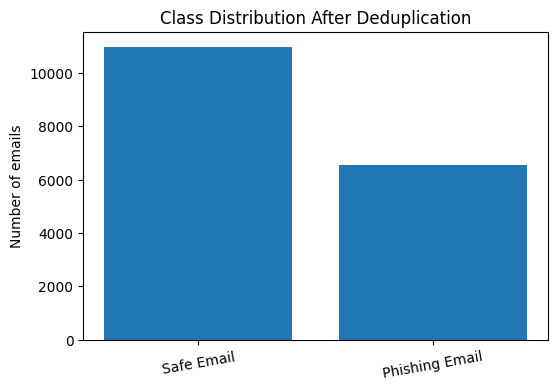

In [5]:
class_balance = (
    df["label"]
      .value_counts()
      .sort_index()
      .rename_axis("label")
      .reset_index(name="count")
)
class_balance["Email Type"] = class_balance["label"].map(LABEL_NAME_BY_ID)
class_balance["percentage"] = class_balance["count"] / class_balance["count"].sum() * 100

class_balance = class_balance[["Email Type", "label", "count", "percentage"]]

print(class_balance)
print("Majority/minority ratio:", round(class_balance["count"].max() / class_balance["count"].min(), 2))

plt.figure(figsize=(6, 4))
plt.bar(class_balance["Email Type"], class_balance["count"])
plt.ylabel("Number of emails")
plt.title("Class Distribution After Deduplication")
plt.xticks(rotation=10)
plt.show()


# Split into train, validation, and test sets after deduplication


In [6]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(validation_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())


Train: (12275, 2)
Validation: (2631, 2)
Test: (2631, 2)

Train labels:
label
0    7685
1    4590
Name: count, dtype: int64

Validation labels:
label
0    1647
1     984
Name: count, dtype: int64

Test labels:
label
0    1647
1     984
Name: count, dtype: int64


## Split Balance Check


In [7]:
split_balance = pd.concat([
    train_df.assign(split="train"),
    validation_df.assign(split="validation"),
    test_df.assign(split="test")
])

split_balance_table = (
    split_balance.groupby(["split", "label"])
    .size()
    .rename("count")
    .reset_index()
)
split_balance_table["percentage"] = (
    split_balance_table["count"]
    / split_balance_table.groupby("split")["count"].transform("sum")
    * 100
)

display(split_balance_table)


,split,label,count,percentage
0,test,0,1647,62.599772
1,test,1,984,37.400228
2,train,0,7685,62.606925
3,train,1,4590,37.393075
4,validation,0,1647,62.599772
5,validation,1,984,37.400228


# Verify that deduplication removed train/test overlap


In [8]:
def count_exact_overlap(left, right):
    return len(set(left.astype(str)).intersection(set(right.astype(str))))

print("Train/validation overlap:", count_exact_overlap(train_df["text"], validation_df["text"]))
print("Train/test overlap:", count_exact_overlap(train_df["text"], test_df["text"]))
print("Validation/test overlap:", count_exact_overlap(validation_df["text"], test_df["text"]))


Train/validation overlap: 0
Train/test overlap: 0
Validation/test overlap: 0


# Evaluation Helpers

The helper below reports the same metrics for every model: accuracy, precision/recall/F1 for the phishing class, and macro, micro, and weighted F1. Macro-F1 is especially useful when class balance is imperfect because it gives the safe and phishing classes equal importance.


In [9]:
LABEL_NAMES = ["Safe Email", "Phishing Email"]

def evaluate_predictions(y_true, y_pred, model_name=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_phishing": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_phishing": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_phishing": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    if model_name is not None:
        print(model_name)
        print(pd.Series(metrics).round(4))

    return metrics


def print_classification_report(y_true, y_pred):
    print(classification_report(
        y_true,
        y_pred,
        target_names=LABEL_NAMES,
        zero_division=0
    ))


def softmax_positive_class(logits):
    """Convert binary-classification logits to phishing-class probabilities."""
    logits = np.asarray(logits)
    shifted_logits = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(shifted_logits)
    probabilities = exp_logits / exp_logits.sum(axis=1, keepdims=True)
    return probabilities[:, 1]


def evaluate_thresholds(y_true, positive_scores, thresholds=None):
    """Evaluate phishing-class metrics across decision thresholds."""
    if thresholds is None:
        thresholds = np.round(np.arange(0.05, 0.951, 0.01), 2)

    rows = []

    for threshold in thresholds:
        y_pred = (np.asarray(positive_scores) >= threshold).astype(int)
        row = {"threshold": threshold}
        row.update(evaluate_predictions(y_true, y_pred))
        rows.append(row)

    return pd.DataFrame(rows)


def find_best_threshold(y_true, positive_scores, sort_by="f1_phishing"):
    """Choose the threshold using the validation set only."""
    threshold_table = evaluate_thresholds(y_true, positive_scores)

    best_row = (
        threshold_table
        .sort_values([sort_by, "recall_phishing", "precision_phishing"], ascending=False)
        .iloc[0]
    )

    best_threshold = float(best_row["threshold"])

    return threshold_table, best_threshold, best_row.to_dict()

# Classical Model

TF-IDF + Logistic Regression

In [10]:
X_train = train_df["text"]
y_train = train_df["label"]

X_validation = validation_df["text"]
y_validation = validation_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

In [11]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000)),
    ("logreg", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

lr_pipeline.fit(X_train, y_train)

lr_validation_scores = lr_pipeline.predict_proba(X_validation)[:, 1]

lr_threshold_table, lr_best_threshold, lr_validation_threshold_metrics = find_best_threshold(
    y_validation,
    lr_validation_scores,
    sort_by="f1_phishing"
)

print("Best Logistic Regression threshold:", lr_best_threshold)
display(lr_threshold_table.sort_values("f1_phishing", ascending=False).head(10).round(4))

lr_test_scores = lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr = (lr_test_scores >= lr_best_threshold).astype(int)

lr_metrics = evaluate_predictions(y_test, y_pred_lr, "TF-IDF + Logistic Regression")
lr_accuracy = lr_metrics["accuracy"]
lr_f1 = lr_metrics["f1_phishing"]

print_classification_report(y_test, y_pred_lr)

vectorizer = lr_pipeline.named_steps["tfidf"]
clf = lr_pipeline.named_steps["logreg"]


Best Logistic Regression threshold: 0.45


,threshold,accuracy,precision_phishing,recall_phishing,f1_phishing,f1_macro,f1_micro,f1_weighted
40,0.45,0.9764,0.9685,0.9685,0.9685,0.9748,0.9764,0.9764
41,0.46,0.9764,0.9695,0.9675,0.9685,0.9748,0.9764,0.9764
39,0.44,0.9761,0.9666,0.9695,0.9680,0.9744,0.9761,0.9761
38,0.43,0.9749,0.9627,0.9705,0.9666,0.9733,0.9749,0.9749
37,0.42,0.9742,0.9608,0.9705,0.9656,0.9725,0.9742,0.9742
42,0.47,0.9742,0.9702,0.9604,0.9653,0.9723,0.9742,0.9741
36,0.41,0.9738,0.9589,0.9715,0.9652,0.9721,0.9738,0.9738
35,0.40,0.9730,0.9570,0.9715,0.9642,0.9713,0.9730,0.9731
43,0.48,0.9723,0.9701,0.9553,0.9626,0.9703,0.9723,0.9722
32,0.37,0.9711,0.9434,0.9817,0.9622,0.9694,0.9711,0.9712


TF-IDF + Logistic Regression
accuracy              0.9814
precision_phishing    0.9708
recall_phishing       0.9797
f1_phishing           0.9752
f1_macro              0.9801
f1_micro              0.9814
f1_weighted           0.9814
dtype: float64
                precision    recall  f1-score   support

    Safe Email       0.99      0.98      0.99      1647
Phishing Email       0.97      0.98      0.98       984

      accuracy                           0.98      2631
     macro avg       0.98      0.98      0.98      2631
  weighted avg       0.98      0.98      0.98      2631



## Imbalance-Aware Training Methods

For imbalanced binary text classification, useful methods include stratified train/validation/test splits, class-weighted loss, oversampling the minority class, threshold tuning, and focal loss. This notebook already uses stratified splitting. The next cell tests class weighting for the classical model; a class-weighted BERT option is added in the transformer section.


In [12]:
balanced_lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000)),
    ("logreg", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

balanced_lr_pipeline.fit(X_train, y_train)

balanced_validation_scores = balanced_lr_pipeline.predict_proba(X_validation)[:, 1]

(
    balanced_threshold_table,
    balanced_best_threshold,
    balanced_validation_threshold_metrics
) = find_best_threshold(
    y_validation,
    balanced_validation_scores,
    sort_by="f1_phishing"
)

print("Best balanced Logistic Regression threshold:", balanced_best_threshold)
display(balanced_threshold_table.sort_values("f1_phishing", ascending=False).head(10).round(4))

balanced_test_scores = balanced_lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr_balanced = (balanced_test_scores >= balanced_best_threshold).astype(int)

lr_balanced_metrics = evaluate_predictions(
    y_test,
    y_pred_lr_balanced,
    "TF-IDF + Logistic Regression (class_weight='balanced')"
)

print_classification_report(y_test, y_pred_lr_balanced)


Best balanced Logistic Regression threshold: 0.54


,threshold,accuracy,precision_phishing,recall_phishing,f1_phishing,f1_macro,f1_micro,f1_weighted
49,0.54,0.9768,0.9695,0.9685,0.9690,0.9752,0.9768,0.9768
50,0.55,0.9764,0.9695,0.9675,0.9685,0.9748,0.9764,0.9764
48,0.53,0.9757,0.9656,0.9695,0.9675,0.9740,0.9757,0.9757
51,0.56,0.9757,0.9713,0.9634,0.9673,0.9740,0.9757,0.9757
47,0.52,0.9753,0.9637,0.9705,0.9671,0.9737,0.9753,0.9753
46,0.51,0.9742,0.9608,0.9705,0.9656,0.9725,0.9742,0.9742
45,0.50,0.9734,0.9579,0.9715,0.9647,0.9717,0.9734,0.9734
52,0.57,0.9726,0.9730,0.9533,0.9630,0.9707,0.9726,0.9726
42,0.47,0.9719,0.9496,0.9766,0.9629,0.9701,0.9719,0.9720
44,0.49,0.9719,0.9532,0.9726,0.9628,0.9701,0.9719,0.9719


TF-IDF + Logistic Regression (class_weight='balanced')
accuracy              0.9814
precision_phishing    0.9698
recall_phishing       0.9807
f1_phishing           0.9752
f1_macro              0.9802
f1_micro              0.9814
f1_weighted           0.9814
dtype: float64
                precision    recall  f1-score   support

    Safe Email       0.99      0.98      0.99      1647
Phishing Email       0.97      0.98      0.98       984

      accuracy                           0.98      2631
     macro avg       0.98      0.98      0.98      2631
  weighted avg       0.98      0.98      0.98      2631



# Transformer Model

Install packages

Conversion to HuggingFace Datasets (for BERT's Trainer)


In [13]:
dataset = DatasetDict({
    "train": Dataset.from_pandas(
        train_df[["text", "label"]].reset_index(drop=True),
        preserve_index=False
    ),
    "validation": Dataset.from_pandas(
        validation_df[["text", "label"]].reset_index(drop=True),
        preserve_index=False
    ),
    "test": Dataset.from_pandas(
        test_df[["text", "label"]].reset_index(drop=True),
        preserve_index=False
    )
})

print(dataset)
print(dataset["train"].column_names)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 12275
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2631
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2631
    })
})
['text', 'label']


Load Tokenizer and BERT



In [14]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
def get_token_lengths(text_series, batch_size=256):
    lengths = []
    texts = text_series.astype(str).tolist()

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]

        encoded = tokenizer(
            batch_texts,
            truncation=False,
            padding=False,
            add_special_tokens=True
        )

        lengths.extend(len(input_ids) for input_ids in encoded["input_ids"])

    return pd.Series(lengths)


train_token_lengths = get_token_lengths(train_df["text"])
validation_token_lengths = get_token_lengths(validation_df["text"])
test_token_lengths = get_token_lengths(test_df["text"])

truncation_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "mean_tokens": [
        train_token_lengths.mean(),
        validation_token_lengths.mean(),
        test_token_lengths.mean()
    ],
    "median_tokens": [
        train_token_lengths.median(),
        validation_token_lengths.median(),
        test_token_lengths.median()
    ],
    "p95_tokens": [
        train_token_lengths.quantile(0.95),
        validation_token_lengths.quantile(0.95),
        test_token_lengths.quantile(0.95)
    ],
    f"pct_longer_than_{MAX_LENGTH}": [
        (train_token_lengths > MAX_LENGTH).mean() * 100,
        (validation_token_lengths > MAX_LENGTH).mean() * 100,
        (test_token_lengths > MAX_LENGTH).mean() * 100
    ]
})

display(truncation_summary.round(2))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1557 > 512). Running this sequence through the model will result in indexing errors


,split,mean_tokens,median_tokens,p95_tokens,pct_longer_than_128
0,train,820.32,245.0,1523.5,71.80
1,validation,486.30,250.0,1640.0,72.60
2,test,450.31,228.0,1505.5,68.68


Tokenizing the Dataset

In [16]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

# Remove text column after tokenization
if "text" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.remove_columns(["text"])

# Rename label to labels because Trainer expects "labels"
if "label" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

tokenized_dataset.reset_format()

print(tokenized_dataset["train"].column_names)

Map:   0%|          | 0/12275 [00:00<?, ? examples/s]

Map:   0%|          | 0/2631 [00:00<?, ? examples/s]

Map:   0%|          | 0/2631 [00:00<?, ? examples/s]

['labels', 'input_ids', 'token_type_ids', 'attention_mask']


Removal of Unused Columns + Set Torch Format

In [17]:
if "text" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.remove_columns(["text"])

if "label" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

tokenized_dataset.reset_format()

print(tokenized_dataset["train"].column_names)

['labels', 'input_ids', 'token_type_ids', 'attention_mask']


Definition of Metrics

In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision_phishing": precision_score(labels, predictions, pos_label=1, zero_division=0),
        "recall_phishing": recall_score(labels, predictions, pos_label=1, zero_division=0),
        "f1_phishing": f1_score(labels, predictions, pos_label=1, zero_division=0),
        "f1_macro": f1_score(labels, predictions, average="macro", zero_division=0),
        "f1_weighted": f1_score(labels, predictions, average="weighted", zero_division=0),
    }

Training Arguments

In [19]:
training_args = TrainingArguments(
    output_dir="./bert-phishing-results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_phishing",
    greater_is_better=True,
    seed=RANDOM_STATE,
    report_to="none"
)

Trainer

In [20]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

## Class-Weighted BERT Fine-Tuning

The standard BERT run is kept as the main transformer baseline. If the class imbalance becomes more severe, set `RUN_CLASS_WEIGHTED_BERT = True` before training to use a weighted cross-entropy loss. This is useful when false negatives on phishing emails are especially costly.


In [21]:
import torch
from sklearn.utils.class_weight import compute_class_weight

RUN_CLASS_WEIGHTED_BERT = True

bert_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].values
)
bert_class_weights = torch.tensor(bert_class_weights, dtype=torch.float)

class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels", None)
        if labels is None:
            labels = inputs.pop("label")

        outputs = model(**inputs)
        loss_function = torch.nn.CrossEntropyLoss(
            weight=bert_class_weights.to(outputs.logits.device)
        )
        loss = loss_function(
            outputs.logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )
        return (loss, outputs) if return_outputs else loss

if RUN_CLASS_WEIGHTED_BERT:
    trainer = WeightedLossTrainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        compute_metrics=compute_metrics
    )
    print("Using class-weighted BERT Trainer")
else:
    print("Using standard BERT Trainer. Set RUN_CLASS_WEIGHTED_BERT=True to train with class weights.")


Using class-weighted BERT Trainer


Fine-tuning BERT

In [22]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Phishing,Recall Phishing,F1 Phishing,F1 Macro,F1 Weighted
1,0.075224,0.084541,0.980996,0.961462,0.988821,0.974950,0.979820,0.981048
2,0.015050,0.084185,0.988597,0.989733,0.979675,0.984678,0.987799,0.988586


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=3070, training_loss=0.07591892313879553, metrics={'train_runtime': 685.2162, 'train_samples_per_second': 35.828, 'train_steps_per_second': 4.48, 'total_flos': 1614844102272000.0, 'train_loss': 0.07591892313879553, 'epoch': 2.0})

Validation evaluation after training


In [23]:
bert_validation_results = trainer.evaluate(tokenized_dataset["validation"])
print(bert_validation_results)

bert_validation_predictions = trainer.predict(tokenized_dataset["validation"])
bert_validation_scores = softmax_positive_class(
    bert_validation_predictions.predictions
)

y_validation_bert = np.array(validation_df["label"])

(
    bert_threshold_table,
    bert_best_threshold,
    bert_validation_threshold_metrics
) = find_best_threshold(
    y_validation_bert,
    bert_validation_scores,
    sort_by="f1_phishing"
)

print("Best BERT threshold:", bert_best_threshold)
display(
    bert_threshold_table
    .sort_values("f1_phishing", ascending=False)
    .head(10)
    .round(4)
)

Training Loss,Validation Loss,Epoch,Accuracy,Precision Phishing,Recall Phishing,F1 Phishing,F1 Macro,F1 Weighted
0.015050,0.084185,2,0.988597,0.989733,0.979675,0.984678,0.987799,0.988586


{'eval_loss': 0.08418534696102142, 'eval_accuracy': 0.9885974914481186, 'eval_precision_phishing': 0.9897330595482546, 'eval_recall_phishing': 0.9796747967479674, 'eval_f1_phishing': 0.9846782431052093, 'eval_f1_macro': 0.9877991699787547, 'eval_f1_weighted': 0.9885856293163301}


Best BERT threshold: 0.08


,threshold,accuracy,precision_phishing,recall_phishing,f1_phishing,f1_macro,f1_micro,f1_weighted
5,0.10,0.989,0.9877,0.9827,0.9852,0.9882,0.989,0.989
4,0.09,0.989,0.9877,0.9827,0.9852,0.9882,0.989,0.989
3,0.08,0.989,0.9877,0.9827,0.9852,0.9882,0.989,0.989
7,0.12,0.989,0.9877,0.9827,0.9852,0.9882,0.989,0.989
8,0.13,0.989,0.9877,0.9827,0.9852,0.9882,0.989,0.989
9,0.14,0.989,0.9877,0.9827,0.9852,0.9882,0.989,0.989
6,0.11,0.989,0.9877,0.9827,0.9852,0.9882,0.989,0.989
10,0.15,0.989,0.9877,0.9827,0.9852,0.9882,0.989,0.989
16,0.21,0.989,0.9887,0.9817,0.9852,0.9882,0.989,0.989
18,0.23,0.989,0.9887,0.9817,0.9852,0.9882,0.989,0.989


Final test-set classification report


In [24]:
import time

start_time = time.time()

print("Running BERT prediction on test set...")
print("Test set size:", len(tokenized_dataset["test"]))
print("Columns:", tokenized_dataset["test"].column_names)

bert_predictions = trainer.predict(tokenized_dataset["test"])

bert_test_scores = softmax_positive_class(
    bert_predictions.predictions
)

y_true_bert = np.array(test_df["label"])
y_pred_bert = (bert_test_scores >= bert_best_threshold).astype(int)

bert_metrics = evaluate_predictions(
    y_true_bert,
    y_pred_bert,
    "BERT"
)

bert_accuracy = bert_metrics["accuracy"]
bert_f1 = bert_metrics["f1_phishing"]

print_classification_report(y_true_bert, y_pred_bert)

elapsed = time.time() - start_time
print(f"BERT test prediction finished in {elapsed:.2f} seconds.")

Running BERT prediction on test set...
Test set size: 2631
Columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


BERT
accuracy              0.9875
precision_phishing    0.9847
recall_phishing       0.9817
f1_phishing           0.9832
f1_macro              0.9866
f1_micro              0.9875
f1_weighted           0.9875
dtype: float64
                precision    recall  f1-score   support

    Safe Email       0.99      0.99      0.99      1647
Phishing Email       0.98      0.98      0.98       984

      accuracy                           0.99      2631
     macro avg       0.99      0.99      0.99      2631
  weighted avg       0.99      0.99      0.99      2631

BERT test prediction finished in 18.76 seconds.


# Zero-Shot Transformer Baseline




In [25]:
zero_shot_metrics = None

if RUN_ZERO_SHOT:
    from transformers import pipeline

    zero_shot_classifier = pipeline(
        "zero-shot-classification",
        model=ZERO_SHOT_MODEL,
        device=0 if torch.cuda.is_available() else -1
    )

    zero_shot_sample_size = min(ZERO_SHOT_SAMPLE_SIZE, len(test_df))

    if zero_shot_sample_size == len(test_df):
        zero_shot_df = test_df.copy().reset_index(drop=True)
    else:
        _, zero_shot_df = train_test_split(
            test_df,
            test_size=zero_shot_sample_size,
            random_state=RANDOM_STATE,
            stratify=test_df["label"]
        )
        zero_shot_df = zero_shot_df.reset_index(drop=True)

    candidate_labels = ["safe email", "phishing email"]
    zero_shot_predictions = []

    for text in zero_shot_df["text"]:
        result = zero_shot_classifier(
            text[:2000],
            candidate_labels=candidate_labels,
            hypothesis_template="This message is a {}."
        )

        zero_shot_predictions.append(
            1 if result["labels"][0] == "phishing email" else 0
        )

    zero_shot_metrics = evaluate_predictions(
        zero_shot_df["label"],
        zero_shot_predictions,
        f"Zero-shot NLI ({ZERO_SHOT_MODEL})"
    )

    print_classification_report(zero_shot_df["label"], zero_shot_predictions)

else:
    print("Zero-shot baseline skipped. Set RUN_ZERO_SHOT=True to run the sampled zero-shot experiment.")


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Zero-shot NLI (facebook/bart-large-mnli)
accuracy              0.6200
precision_phishing    0.4615
recall_phishing       0.0800
f1_phishing           0.1364
f1_macro              0.4464
f1_micro              0.6200
f1_weighted           0.5239
dtype: float64
                precision    recall  f1-score   support

    Safe Email       0.63      0.94      0.76       125
Phishing Email       0.46      0.08      0.14        75

      accuracy                           0.62       200
     macro avg       0.55      0.51      0.45       200
  weighted avg       0.57      0.62      0.52       200



# Classical Model VS Transformer Model

The comparison below uses the held-out test set. BERT uses the validation set during training/checkpoint selection, so the test set remains unseen until final evaluation.


Comparison Table

In [26]:
result_rows = [
    {
        "Model": "TF-IDF + Logistic Regression",
        "threshold": lr_best_threshold,
        **lr_metrics
    },
    {
        "Model": "TF-IDF + Logistic Regression (balanced)",
        "threshold": balanced_best_threshold,
        **lr_balanced_metrics
    },
    {
        "Model": "BERT",
        "threshold": bert_best_threshold,
        **bert_metrics
    },
]

if zero_shot_metrics is not None:
    result_rows.append({
        "Model": "Zero-shot NLI",
        "threshold": np.nan,
        **zero_shot_metrics
    })

results_table = pd.DataFrame(result_rows)

metric_columns = [
    "accuracy",
    "precision_phishing",
    "recall_phishing",
    "f1_phishing",
    "f1_macro",
    "f1_micro",
    "f1_weighted"
]

display(results_table[["Model", "threshold"] + metric_columns].round(4))

results_table.to_csv("model_comparison_results.csv", index=False)

print("Saved results to model_comparison_results.csv")

,Model,threshold,accuracy,precision_phishing,recall_phishing,f1_phishing,f1_macro,f1_micro,f1_weighted
0,TF-IDF + Logistic Regression,0.45,0.9814,0.9708,0.9797,0.9752,0.9801,0.9814,0.9814
1,TF-IDF + Logistic Regression (balanced),0.54,0.9814,0.9698,0.9807,0.9752,0.9802,0.9814,0.9814
2,BERT,0.08,0.9875,0.9847,0.9817,0.9832,0.9866,0.9875,0.9875
3,Zero-shot NLI,NaN,0.6200,0.4615,0.0800,0.1364,0.4464,0.6200,0.5239


Saved results to model_comparison_results.csv


- The results show that BERT achieves the strongest overall performance, with the highest accuracy and F1-scores. The class-weighted Logistic Regression model slightly improves phishing recall compared with the standard Logistic Regression model, which is important because missing phishing emails is more harmful than incorrectly flagging a safe email. The zero-shot NLI baseline performs much worse, especially on phishing recall, showing that task-specific training is necessary for reliable phishing email detection.

## Comparison Bar charts

Accuracy Bar charts

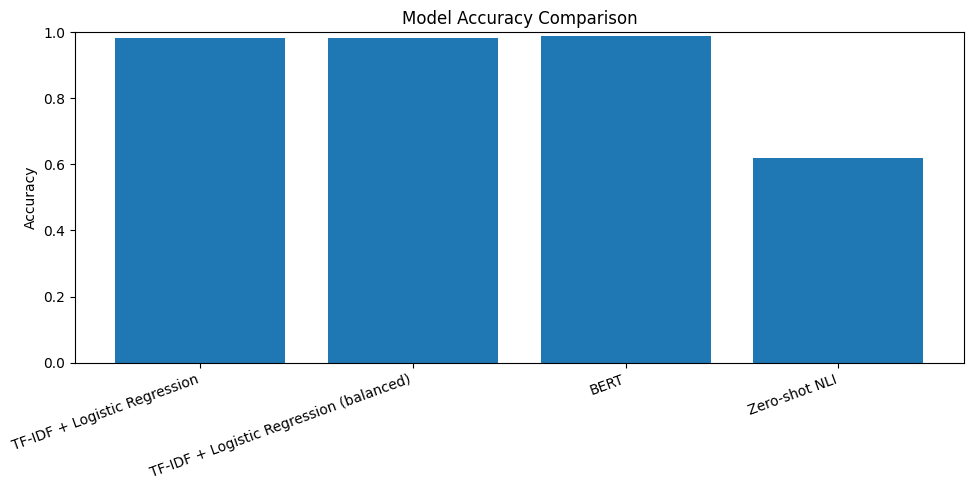

In [27]:
plt.figure(figsize=(10, 5))
plt.bar(results_table["Model"], results_table["accuracy"])
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


The next chart compares F1 variants. `f1_phishing` focuses on the positive phishing class, `f1_macro` gives equal weight to both classes, `f1_micro` aggregates all decisions, and `f1_weighted` accounts for class support.


F1-Score Bar Charts

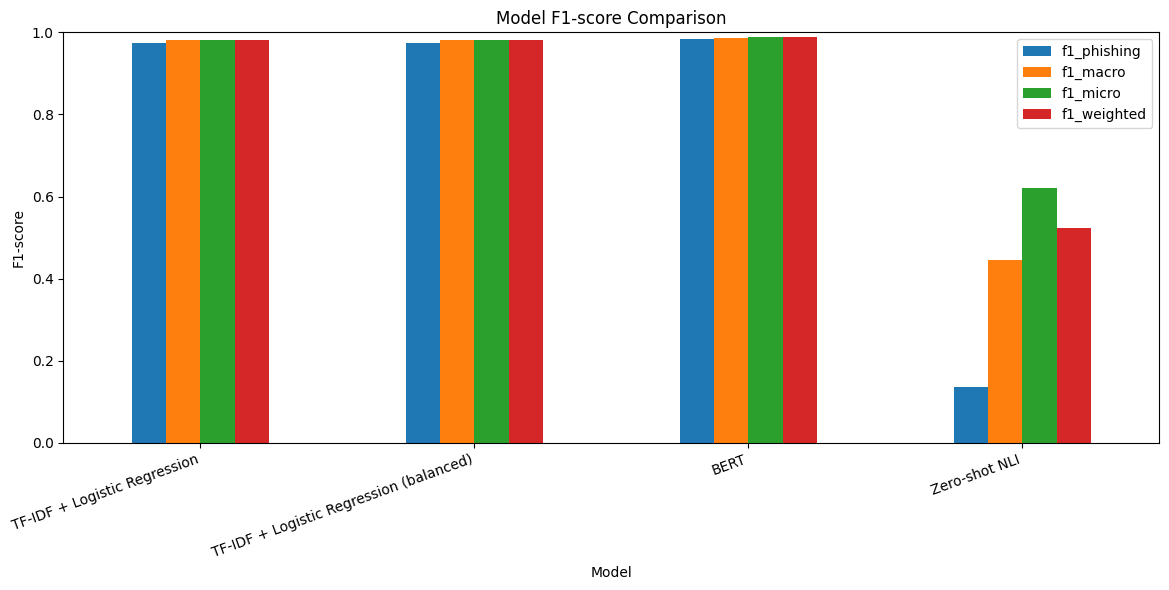

In [28]:
f1_columns = ["f1_phishing", "f1_macro", "f1_micro", "f1_weighted"]

results_table.set_index("Model")[f1_columns].plot(kind="bar", figsize=(12, 6))
plt.ylabel("F1-score")
plt.title("Model F1-score Comparison")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## Confusion Matrices

For Logistic Regression

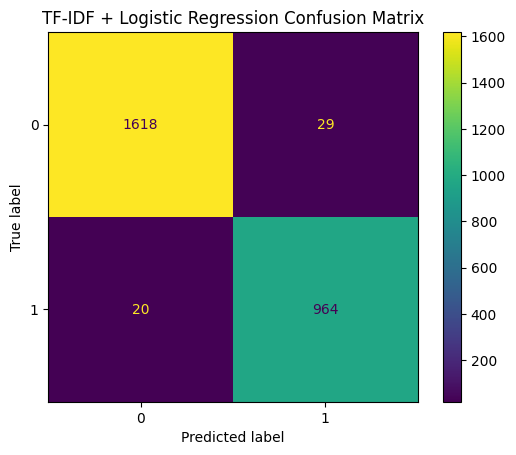

In [29]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()
plt.title("TF-IDF + Logistic Regression Confusion Matrix")
plt.show()


For BERT

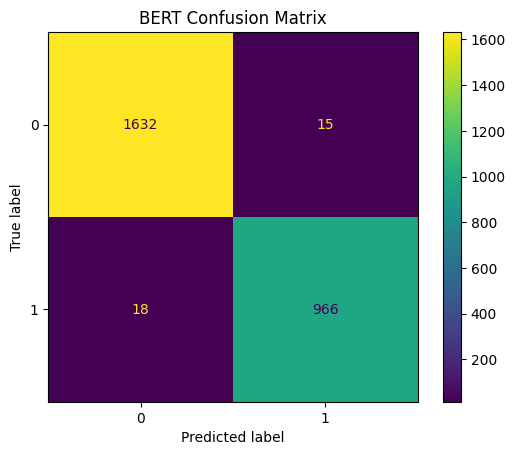

In [30]:
cm_bert = confusion_matrix(y_true_bert, y_pred_bert)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_bert)
disp.plot()
plt.title("BERT Confusion Matrix")
plt.show()

## Misclassified Emails for each Model


In [31]:
misclassified_lr = np.where(np.array(y_test) != np.array(y_pred_lr))[0]
misclassified_bert = np.where(np.array(y_true_bert) != np.array(y_pred_bert))[0]

print("TF-IDF misclassified:", len(misclassified_lr))
print("BERT misclassified:", len(misclassified_bert))


TF-IDF misclassified: 49
BERT misclassified: 33


Examples of Misclassified Emails


For TF-IDF

In [32]:
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

for idx in misclassified_lr[:5]:
    print("=" * 80)
    print("TF-IDF misclassified example")
    print("Text:")
    print(X_test_reset.iloc[idx][:1000])
    print()
    print("True label:", y_test_reset.iloc[idx])
    print("Predicted label:", y_pred_lr[idx])


TF-IDF misclassified example
Text:
Industrial LINUX News: The June issue of the ISA's InTech Magazine has an interesting article on how truly open Linux applications can lower development cost and increase the performance and reliability of industrial automation. A copy of the the article can be found at:  http://www.sixnet-io.com/html_files/web_articles/linux_article_info.htm
This Linux news update brought to you by:  www.Linux4oems.info ------------------------------------------------------------------------------If you don't want to receive future Linux news updates, please reply to this e-mail with the subject "unsubscribe".  You may also unsubscribe or resolve subscription difficulties by calling SIXNET at 518-877-5173 or e-mailing:  linuxnews@sixnet-io.com
.naorwnwbxbsttgvelamusbs


True label: 1
Predicted label: 0
TF-IDF misclassified example
Text:
q : new email address for pier marco bertinetto content - length : 83 since the old address no longer works , would anybody know the

For BERT

In [33]:
for idx in misclassified_bert[:5]:
    print("=" * 80)
    print("BERT misclassified example")
    print("Text:")
    print(test_df.reset_index(drop=True).iloc[idx]["text"][:1000])
    print()
    print("True label:", test_df.reset_index(drop=True).iloc[idx]["label"])
    print("Predicted label:", y_pred_bert[idx])

BERT misclassified example
Text:
Industrial LINUX News: The June issue of the ISA's InTech Magazine has an interesting article on how truly open Linux applications can lower development cost and increase the performance and reliability of industrial automation. A copy of the the article can be found at:  http://www.sixnet-io.com/html_files/web_articles/linux_article_info.htm
This Linux news update brought to you by:  www.Linux4oems.info ------------------------------------------------------------------------------If you don't want to receive future Linux news updates, please reply to this e-mail with the subject "unsubscribe".  You may also unsubscribe or resolve subscription difficulties by calling SIXNET at 518-877-5173 or e-mailing:  linuxnews@sixnet-io.com
.naorwnwbxbsttgvelamusbs


True label: 1
Predicted label: 0
BERT misclassified example
Text:
if (window.Event) // Only Netscape will have the CAPITAL E.
  document.captureEvents(Event.MOUSEUP); // catch the mouse up event
functio

# Explainability (XAI) for Text Classification

For the TF-IDF model, the logistic regression coefficients provide a direct explanation: positive coefficients push the prediction toward phishing, while negative coefficients push it toward safe email. For transformer models, common XAI methods include LIME, SHAP, Integrated Gradients, attention visualization, and token-occlusion tests.


In [34]:
vectorizer = lr_pipeline.named_steps["tfidf"]
clf = lr_pipeline.named_steps["logreg"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = clf.coef_[0]
top_n = 20

top_phishing_idx = np.argsort(coefficients)[-top_n:][::-1]
top_safe_idx = np.argsort(coefficients)[:top_n]

xai_terms = pd.concat([
    pd.DataFrame({
        "class_direction": "Phishing Email",
        "term": feature_names[top_phishing_idx],
        "coefficient": coefficients[top_phishing_idx]
    }),
    pd.DataFrame({
        "class_direction": "Safe Email",
        "term": feature_names[top_safe_idx],
        "coefficient": coefficients[top_safe_idx]
    })
])

display(xai_terms)

,class_direction,term,coefficient
0,Phishing Email,click,4.030270
1,Phishing Email,2005,3.842217
2,Phishing Email,remove,3.653867
3,Phishing Email,sightings,3.576632
4,Phishing Email,money,3.490685
5,Phishing Email,free,3.366197
6,Phishing Email,2004,3.281964
7,Phishing Email,email,3.005216
8,Phishing Email,site,2.723961
9,Phishing Email,life,2.679288


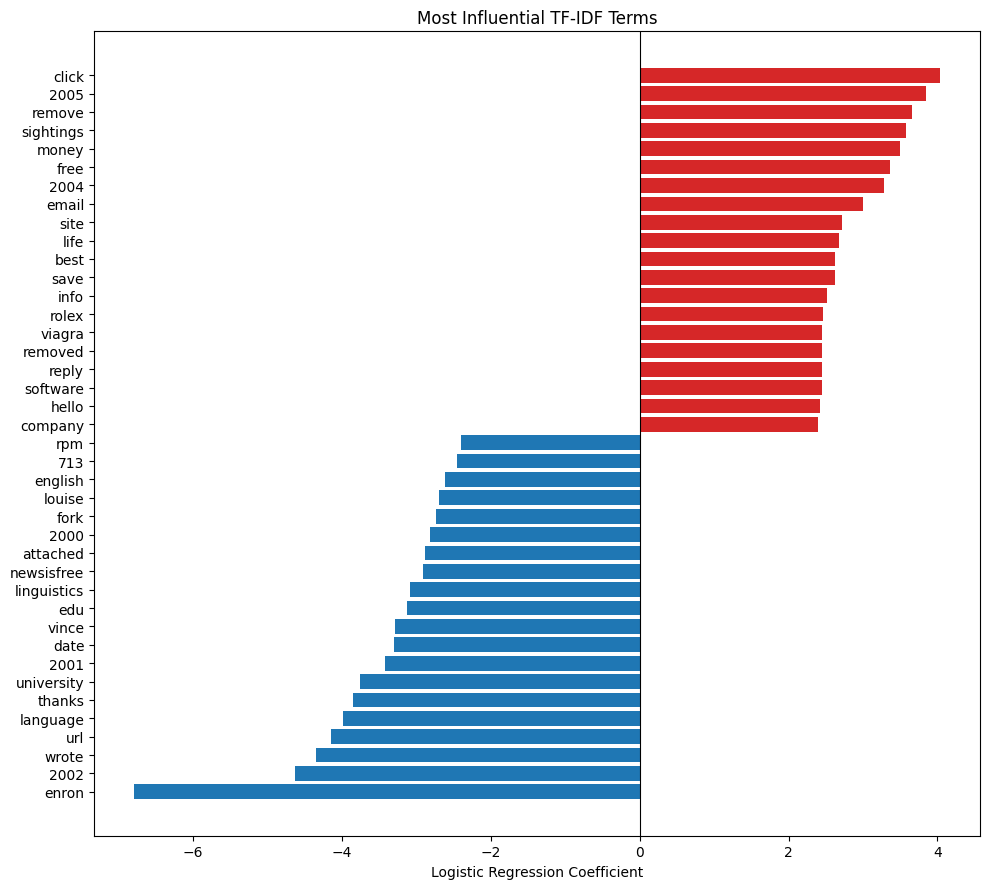

In [35]:
plot_terms = pd.concat([
    xai_terms[xai_terms["class_direction"] == "Safe Email"].sort_values("coefficient"),
    xai_terms[xai_terms["class_direction"] == "Phishing Email"].sort_values("coefficient")
])
colors = plot_terms["class_direction"].map({"Safe Email": "tab:blue", "Phishing Email": "tab:red"})

plt.figure(figsize=(10, 9))
plt.barh(plot_terms["term"], plot_terms["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Logistic Regression Coefficient")
plt.title("Most Influential TF-IDF Terms")
plt.tight_layout()
plt.show()


In [36]:
def explain_lr_email(text, top_n=15):
    tfidf_row = vectorizer.transform([text])
    contributions = tfidf_row.multiply(clf.coef_).toarray()[0]
    nonzero_idx = np.flatnonzero(contributions)

    explanation = pd.DataFrame({
        "term": feature_names[nonzero_idx],
        "contribution": contributions[nonzero_idx]
    })
    explanation["absolute_contribution"] = explanation["contribution"].abs()
    return explanation.sort_values("absolute_contribution", ascending=False).head(top_n)

example_idx = 0
print("True label:", y_test.reset_index(drop=True).iloc[example_idx])
print("Predicted label:", y_pred_lr[example_idx])
display(explain_lr_email(X_test.reset_index(drop=True).iloc[example_idx]))


True label: 0
Predicted label: 0


,term,contribution,absolute_contribution
11,enron,-0.740874,0.740874
2,2000,-0.682449,0.682449
17,xls,-0.638713,0.638713
14,hpl,-0.571793,0.571793
8,changes,-0.457067,0.457067
6,attached,-0.385212,0.385212
1,10,-0.279043,0.279043
12,file,-0.256693,0.256693
13,forwarded,-0.224741,0.224741
0,06,-0.214165,0.214165


# Second Dataset Comparison

To check whether the results are specific to one dataset, this section loads an additional phishing benchmark: the phishing domain from [`difraud/difraud`](https://huggingface.co/datasets/difraud/difraud), which uses the same binary convention (`text`, `label`, where `1` means deceptive/phishing). The comparison uses TF-IDF + Logistic Regression because it is fast enough to repeat across datasets.

In [37]:
secondary_ds = load_dataset(
    "json",
    data_files={
        "train": "https://huggingface.co/datasets/difraud/difraud/resolve/main/phishing/train.jsonl",
        "validation": "https://huggingface.co/datasets/difraud/difraud/resolve/main/phishing/validation.jsonl",
        "test": "https://huggingface.co/datasets/difraud/difraud/resolve/main/phishing/test.jsonl",
    }
)

secondary_train_df = pd.DataFrame(secondary_ds["train"])[["text", "label"]].dropna().copy()
secondary_validation_df = pd.DataFrame(secondary_ds["validation"])[["text", "label"]].dropna().copy()
secondary_test_df = pd.DataFrame(secondary_ds["test"])[["text", "label"]].dropna().copy()

for frame in [secondary_train_df, secondary_validation_df, secondary_test_df]:
    frame["text"] = frame["text"].astype(str)
    frame["label"] = frame["label"].astype(int)

secondary_full_df = pd.concat(
    [secondary_train_df, secondary_validation_df, secondary_test_df],
    ignore_index=True
)

def summarize_binary_dataset(name, frame):
    counts = frame["label"].value_counts().sort_index()
    return {
        "Dataset": name,
        "Rows": len(frame),
        "Safe/Benign": counts.get(0, 0),
        "Phishing/Deceptive": counts.get(1, 0),
        "Phishing %": counts.get(1, 0) / len(frame) * 100,
        "Average text length": frame["text"].str.len().mean()
    }

phishing/train.jsonl:   0%|          | 0.00/28.3M [00:00<?, ?B/s]

validation.jsonl:   0%|          | 0.00/3.41M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/3.32M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [38]:
df_model = df[["text", "label"]].dropna().copy()
df_model["text"] = df_model["text"].astype(str)
df_model["label"] = df_model["label"].astype(int)

dataset_summary = pd.DataFrame([
    summarize_binary_dataset("zefang-liu/phishing-email-dataset", df_model),
    summarize_binary_dataset("difraud/difraud phishing", secondary_full_df)
])

display(dataset_summary.round(2))


,Dataset,Rows,Safe/Benign,Phishing/Deceptive,Phishing %,Average text length
0,zefang-liu/phishing-email-dataset,17537,10979,6558,37.40,2861.99
1,difraud/difraud phishing,15272,9198,6074,39.77,2260.79


In [39]:
secondary_train_plus_validation_df = pd.concat(
    [secondary_train_df, secondary_validation_df],
    ignore_index=True
)

secondary_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000)),
    ("logreg", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

secondary_pipeline.fit(
    secondary_train_plus_validation_df["text"],
    secondary_train_plus_validation_df["label"]
)

# 1. Train and test on the secondary dataset
secondary_predictions = secondary_pipeline.predict(secondary_test_df["text"])

secondary_lr_metrics = evaluate_predictions(
    secondary_test_df["label"],
    secondary_predictions,
    "TF-IDF + LR trained/tested on difraud phishing"
)

# 2. Train on the primary dataset, test on the secondary dataset
primary_to_secondary_scores = lr_pipeline.predict_proba(
    secondary_test_df["text"]
)[:, 1]

primary_to_secondary_predictions = (
    primary_to_secondary_scores >= lr_best_threshold
).astype(int)

primary_to_secondary_metrics = evaluate_predictions(
    secondary_test_df["label"],
    primary_to_secondary_predictions,
    "Primary-dataset TF-IDF + LR tested on difraud phishing"
)

# 3. Train on the secondary dataset, test on the primary dataset
secondary_to_primary_predictions = secondary_pipeline.predict(test_df["text"])

secondary_to_primary_metrics = evaluate_predictions(
    test_df["label"],
    secondary_to_primary_predictions,
    "Difraud-trained TF-IDF + LR tested on primary test set"
)

# Final comparison table
dataset_model_comparison = pd.DataFrame([
    {
        "Experiment": "Primary train/test",
        **lr_metrics
    },
    {
        "Experiment": "Difraud train/test",
        **secondary_lr_metrics
    },
    {
        "Experiment": "Primary trained -> Difraud test",
        **primary_to_secondary_metrics
    },
    {
        "Experiment": "Difraud trained -> Primary test",
        **secondary_to_primary_metrics
    },
])

display(dataset_model_comparison[["Experiment"] + metric_columns].round(4))

dataset_model_comparison.to_csv(
    "cross_dataset_comparison_results.csv",
    index=False
)

print("Saved cross-dataset results to cross_dataset_comparison_results.csv")


TF-IDF + LR trained/tested on difraud phishing
accuracy              0.9719
precision_phishing    0.9879
recall_phishing       0.9408
f1_phishing           0.9638
f1_macro              0.9704
f1_micro              0.9719
f1_weighted           0.9717
dtype: float64
Primary-dataset TF-IDF + LR tested on difraud phishing
accuracy              0.9051
precision_phishing    0.8360
recall_phishing       0.9474
f1_phishing           0.8882
f1_macro              0.9029
f1_micro              0.9051
f1_weighted           0.9059
dtype: float64
Difraud-trained TF-IDF + LR tested on primary test set
accuracy              0.7948
precision_phishing    0.9703
recall_phishing       0.4654
f1_phishing           0.6291
f1_macro              0.7436
f1_micro              0.7948
f1_weighted           0.7725
dtype: float64


,Experiment,accuracy,precision_phishing,recall_phishing,f1_phishing,f1_macro,f1_micro,f1_weighted
0,Primary train/test,0.9814,0.9708,0.9797,0.9752,0.9801,0.9814,0.9814
1,Difraud train/test,0.9719,0.9879,0.9408,0.9638,0.9704,0.9719,0.9717
2,Primary trained -> Difraud test,0.9051,0.8360,0.9474,0.8882,0.9029,0.9051,0.9059
3,Difraud trained -> Primary test,0.7948,0.9703,0.4654,0.6291,0.7436,0.7948,0.7725


Saved cross-dataset results to cross_dataset_comparison_results.csv
